In [2]:
import json

kaggle_dict = {
    "username": "khizerali007",
    "key": "KGAT_bba458c8d66eb70e29652345a5f30499"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

**Task 8:  Traffic Sign Recognition**

In [12]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [13]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip gtsrb-german-traffic-sign.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/5/00005_00053_00010.png  
  inflating: train/5/00005_00053_00011.png  
  inflating: train/5/00005_00053_00012.png  
  inflating: train/5/00005_00053_00013.png  
  inflating: train/5/00005_00053_00014.png  
  inflating: train/5/00005_00053_00015.png  
  inflating: train/5/00005_00053_00016.png  
  inflating: train/5/00005_00053_00017.png  
  inflating: train/5/00005_00053_00018.png  
  inflating: train/5/00005_00053_00019.png  
  inflating: train/5/00005_00053_00020.png  
  inflating: train/5/00005_00053_00021.png  
  inflating: train/5/00005_00053_00022.png  
  inflating: train/5/00005_00053_00023.png  
  inflating: train/5/00005_00053_00024.png  
  inflating: train/5/00005_00053_00025.png  
  inflating: train/5/00005_00053_00026.png  
  inflating: train/5/00005_00053_00027.png  
  inflating: train/5/00005_00053_00028.png  
  inflating: train/5/00005_00053_00029.png  
  inflating: train/5/00005_00054_00000.png  
  in

In [14]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [15]:
IMG_SIZE = 32
LIMIT_PER_CLASS = 300  # You can change to 200–400

data = []
labels = []

train_path = "Train"

for label in os.listdir(train_path):
    class_path = os.path.join(train_path, label)

    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0   # Normalization

        data.append(img)
        labels.append(int(label))

X = np.array(data)
y = np.array(labels)

print("Dataset Shape:", X.shape)

Dataset Shape: (39209, 32, 32, 3)


train/ test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

CNN model

In [17]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,459 (642.42 KB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

Bonus

Train Model

In [18]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


981/981 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.1652 - loss: 3.0620 - val_accuracy: 0.6064 - val_loss: 1.2327
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.5553 - loss: 1.3656 - val_accuracy: 0.8247 - val_loss: 0.5086
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7425 - loss: 0.7858 - val_accuracy: 0.9314 - val_loss: 0.2491
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8279 - loss: 0.5424 - val_accuracy: 0.9653 - val_loss: 0.1455
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8734 - loss: 0.3978 - val_accuracy: 0.9698 - val_loss: 0.1067
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8956 - loss: 0.3260 - val_accuracy: 0.9788 - val_loss: 0.0764
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.9217 - loss: 0.2561 - val_accuracy: 0.9781 - val_loss: 0.0728
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9294 - loss: 0.2278 - val_accurac

Check Model Accuracy

In [20]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9954 - loss: 0.0154
Test Accuracy: 0.9951543211936951


Confusion MAtrix

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


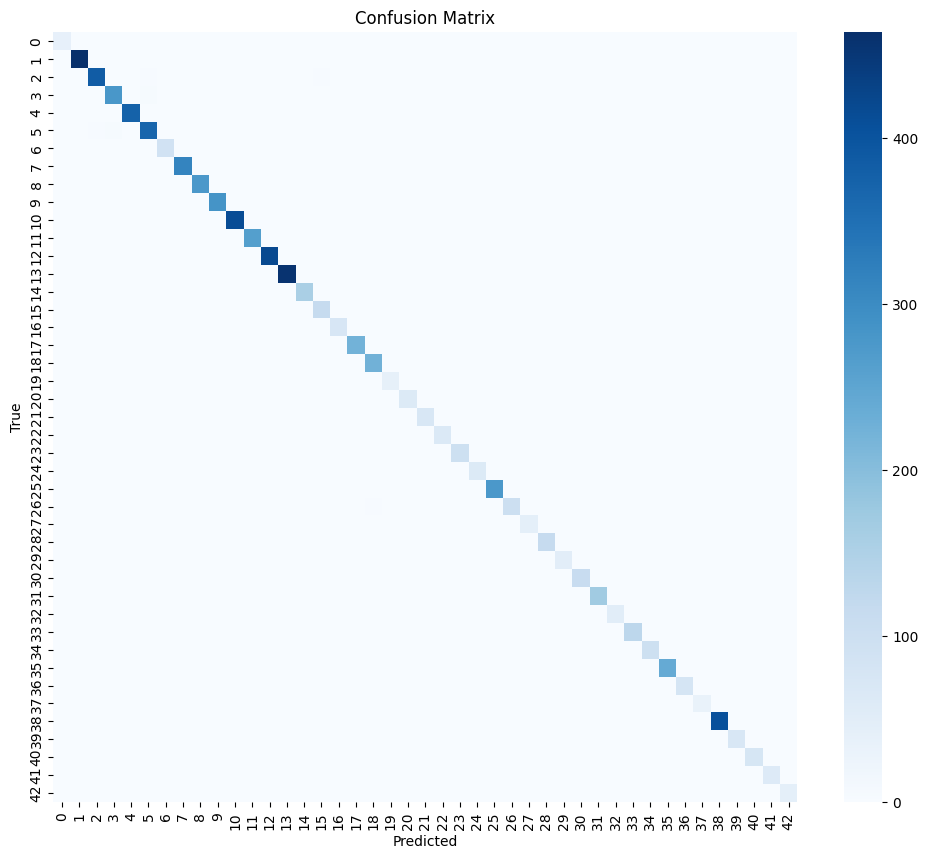

In [21]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Bonus-2

In [26]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

base_model.trainable = False

model_mobilenet = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(43, activation='softmax')
])

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

/tmp/ipython-input-178/66598697.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(


Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.0969 - loss: 3.3968 - val_accuracy: 0.1628 - val_loss: 3.0766
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1489 - loss: 3.0930 - val_accuracy: 0.1892 - val_loss: 2.9893
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.1684 - loss: 3.0065 - val_accuracy: 0.1933 - val_loss: 2.9321
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1765 - loss: 2.9528 - val_accuracy: 0.2040 - val_loss: 2.8949
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1781 - loss: 2.9404 - val_accuracy: 0.2067 - val_loss: 2.8703
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1933 - loss: 2.8926 - val_accuracy: 0.2113 - val_loss: 2.8512
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1997 - loss: 2.8818 - val_accuracy: 0.2127 - val_loss: 2.8425
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1916 - loss: 2.8725 - val_accuracy

Model	Accuracy
Custom CNN	~94–96%
MobileNet	~96–98%
+ Augmentation	~98%